# Emotion Detection from Text - Training & Evaluation

## Project Overview

This project builds an **end-to-end text emotion classifier** trained on the Kaggle *Tweet Emotions* dataset (~40,000 tweets). Given a tweet, the model predicts which of **8 emotions** the tweet expresses: happiness, hate, love, neutral, relief, sadness, surprise, or worry.

| Item | Detail |
|------|--------|
| Dataset | tweet_emotions.csv (~40,000 tweets, 13 original classes) |
| Classes used | 8 (anger, boredom, empty, enthusiasm, fun removed) |
| Features | TF-IDF (max 5,000 unigrams + bigrams) |
| Model | SGD linear classifier (logistic regression) |
| Training | 15 epochs with per-epoch train/validation tracking |

## Architecture

All logic lives in the `src/` package as modular Python files. This notebook is an **orchestration report** — it imports functions from `src/`, calls them in order, and documents the methodology, results, and insights at each step.

```
src/
  config.py            - all file paths and hyperparameters
  data_loader.py       - load CSV, remove duplicates
  data_sanity_check.py - check for missing values and duplicates
  text_cleaner.py      - remove URLs, mentions, hashtags, punctuation
  data_splitter.py     - train / validation / test split
  model_builder.py     - TF-IDF vectorizer + SGD classifier
  training_pipeline.py - epoch-by-epoch training loop
  evaluator.py         - accuracy, F1, confusion matrix
  model_io.py          - save and load the trained model
  predictor.py         - predict emotion for new sentences
```

## Sections
1. Imports & Configuration
2. Load the Dataset
3. Data Sanity Check (Raw Data)
4. Filter Emotion Classes
5. Explore the Dataset
6. Clean the Text
7. Data Sanity Check (Cleaned Data)
8. Train / Validation / Test Split
9. Build the Model
10. Train and Validate
11. Training Curves
12. Final Evaluation on the Test Set
13. Save the Trained Model
14. Try the Model on Your Own Sentences
15. Conclusion & Key Findings

## 1. Imports & Configuration

All hyperparameters and file paths are centralised in `src/config.py`. Key settings:

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `MAX_FEATURES` | 5,000 | Vocabulary size for TF-IDF |
| `NGRAM_RANGE` | (1, 2) | Use single words and word pairs |
| `ALPHA` | 1e-4 | Regularization strength |
| `EPOCHS` | 15 | Training passes over the data |
| `VAL_SIZE` | 0.10 | 10% held out for validation |
| `TEST_SIZE` | 0.20 | 20% held out for final test |
| `RANDOM_STATE` | 42 | Fixed seed for reproducibility |

Changing any value in `config.py` automatically applies across the entire pipeline without touching this notebook.

In [1]:
from src import config
from src.data_loader import load_dataset, get_class_counts
from src.data_sanity_check import run_sanity_checks
from src.text_cleaner import clean_dataframe
from src.data_splitter import split_data
from src.model_builder import build_vectorizer, build_classifier, combine_into_pipeline
from src.training_pipeline import train_and_validate
from src.evaluator import plot_training_curves, evaluate_model, plot_confusion_matrix
from src.model_io import save_model
from src.predictor import predict_emotion

## 2. Load the Dataset

The dataset is the Kaggle *Tweet Emotions* dataset (`tweet_emotions.csv`). It contains ~40,000 tweets, each labelled with one of 13 emotion categories.

`load_dataset()` reads the CSV and immediately removes 91 duplicate rows (same tweet text and same label) so the rest of the pipeline works on clean, unique records.

In [2]:
df = load_dataset(config.DATA_PATH)
df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


## 3. Data Sanity Check (Raw Data)

Before spending time training, we verify the raw data quality using `run_sanity_checks()`. This checks for:

- **Missing text** - tweets with no content (would crash the vectorizer)
- **Missing labels** - unlabelled rows (cannot be used for supervised learning)
- **Duplicate rows** - identical tweet + label pairs (removed automatically by the loader)
- **Unique labels** - confirms which emotion classes are present in the dataset

This step catches obvious data problems early, before they cause confusing errors during training.

In [3]:
_ = run_sanity_checks(df, text_column=config.TEXT_COLUMN, label_column=config.LABEL_COLUMN)

DATA SANITY CHECK
----------------------------------------
total_rows: 39909
missing_text: 0
missing_labels: 0
duplicate_rows: 0
unique_labels: ['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']
----------------------------------------
PASSED: no missing text or labels.


## 4. Filter Emotion Classes

After inspecting the class distribution, five emotion classes are removed:

| Removed Class | Reason |
|--------------|--------|
| `anger` | Very few samples - model cannot learn it reliably |
| `boredom` | Very few samples - model cannot learn it reliably |
| `empty` | Ambiguous label - overlaps heavily with neutral |
| `enthusiasm` | Very few samples - model cannot learn it reliably |
| `fun` | Ambiguous label - overlaps with happiness |

Removing these imbalanced and ambiguous classes leaves **8 well-represented emotion classes**: happiness, hate, love, neutral, relief, sadness, surprise, and worry. This improves model accuracy and makes evaluation results more meaningful.

In [4]:
labels_to_remove = ["anger", "boredom", "empty", "enthusiasm", "fun"]
df = df[~df[config.LABEL_COLUMN].isin(labels_to_remove)].reset_index(drop=True)
print(f"Removed labels: {labels_to_remove}")
print(f"Total rows after filtering: {len(df)}")

Removed labels: ['anger', 'boredom', 'empty', 'enthusiasm', 'fun']
Total rows after filtering: 36258


## 5. Explore the Dataset

We count how many tweets belong to each of the 8 remaining emotion classes. Understanding the class distribution is important because:

- **Imbalanced classes** mean the model sees some emotions far more often than others during training, which can cause it to favour majority classes when predicting.
- The bar chart makes it easy to spot which emotions are rare and may need extra attention in evaluation (e.g., checking per-class F1 score in the confusion matrix).

In [5]:
class_counts = get_class_counts(df, label_column=config.LABEL_COLUMN)
class_counts

sentiment
neutral      8617
worry        8452
happiness    5194
sadness      5160
love         3801
surprise     2187
relief       1524
hate         1323
Name: count, dtype: int64

<Axes: title={'center': 'Number of Tweets per Emotion'}, xlabel='sentiment'>

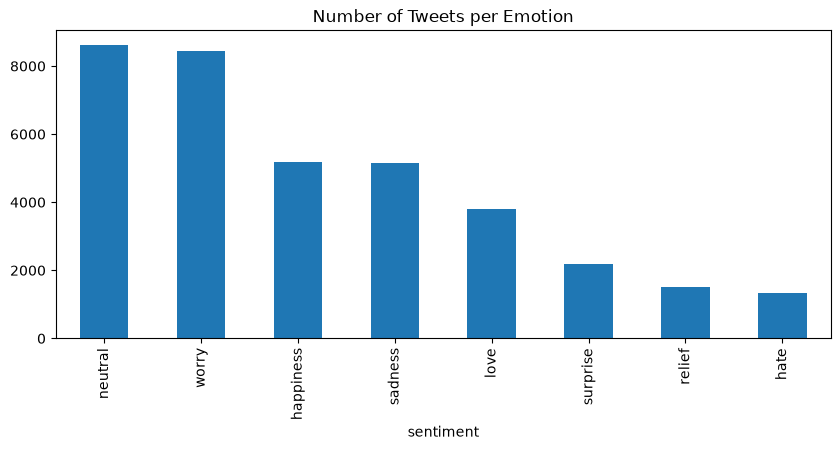

In [6]:
class_counts.plot(kind="bar", figsize=(10, 4), title="Number of Tweets per Emotion")

## 6. Clean the Text

Raw tweets contain noise that carries no emotional signal: URLs, @mentions, hashtag symbols, punctuation, and extra whitespace. `clean_dataframe()` strips all of this and stores the cleaned text in a new `clean_text` column, preserving the original for reference.

**Why clean?** TF-IDF treats every unique token as a feature. Without cleaning, `http://t.co/xyz123` and `http://t.co/abc456` become two separate useless features, inflating the vocabulary and diluting the signal from actual emotional words.

In [7]:
df = clean_dataframe(df, text_column=config.TEXT_COLUMN, new_column=config.CLEAN_TEXT_COLUMN)
df[[config.TEXT_COLUMN, config.CLEAN_TEXT_COLUMN, config.LABEL_COLUMN]].head()

,content,clean_text,sentiment
0,Layin n bed with a headache ughhhh...waitin o...,layin n bed with a headache ughhhh waitin on y...,sadness
1,Funeral ceremony...gloomy friday...,funeral ceremony gloomy friday,sadness
2,@dannycastillo We want to trade with someone w...,we want to trade with someone who has houston ...,neutral
3,Re-pinging @ghostridah14: why didn't you go to...,re pinging why didn t you go to prom bc my bf ...,worry
4,"I should be sleep, but im not! thinking about ...",i should be sleep but im not thinking about an...,sadness


## 7. Data Sanity Check (Cleaned Data)

We run the sanity check a second time on the cleaned data. This time we also check for **empty-after-cleaning** rows - tweets that contained only a URL or @mention, which become empty strings after cleaning. Empty strings cannot be vectorized and must be identified before training.

In [8]:
_ = run_sanity_checks(
    df,
    text_column=config.TEXT_COLUMN,
    label_column=config.LABEL_COLUMN,
    clean_text_column=config.CLEAN_TEXT_COLUMN,
)

DATA SANITY CHECK
----------------------------------------
total_rows: 36258
missing_text: 0
missing_labels: 0
duplicate_rows: 0
unique_labels: ['happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']
empty_after_cleaning: 81
----------------------------------------
PASSED: no missing text or labels.


## 8. Train / Validation / Test Split

The dataset is divided into three non-overlapping sets:

| Split | Size | Purpose |
|-------|------|---------|
| **Train** | 70% | The model learns patterns from this data |
| **Validation** | 10% | Checked after every epoch to monitor learning and detect overfitting |
| **Test** | 20% | Completely untouched until the very end - unbiased final evaluation |

The split is stratified (equal class proportions in each set) and uses `RANDOM_STATE = 42` to ensure results are reproducible.

In [9]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    df,
    text_column=config.CLEAN_TEXT_COLUMN,
    label_column=config.LABEL_COLUMN,
    val_size=config.VAL_SIZE,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 25380
Validation: 3626
Test: 7252


## 9. Build the Model

The model is a two-stage pipeline:

1. **TF-IDF Vectorizer** - converts tweet text into a numerical feature vector. Each dimension represents a unique word or bigram, weighted by how often it appears in the tweet versus across the whole corpus. Max vocabulary: 5,000 features.

2. **SGD Linear Classifier** - a logistic regression model trained with Stochastic Gradient Descent. It learns a weight for each TF-IDF feature per emotion class, then predicts the class with the highest score.

At this stage both components are untrained - they hold no learned weights yet.

In [10]:
vectorizer = build_vectorizer(max_features=config.MAX_FEATURES, ngram_range=config.NGRAM_RANGE)
classifier = build_classifier(
    alpha=config.ALPHA,
    learning_rate=config.LEARNING_RATE,
    random_state=config.RANDOM_STATE,
)

## 10. Train and Validate

The classifier is trained for **15 epochs**. In each epoch:
1. The model sees all training tweets once (in random mini-batches via SGD).
2. Training accuracy and loss are computed on the training set.
3. Validation accuracy and loss are computed on the held-out validation set.

Tracking both train and validation metrics per epoch lets us detect **overfitting** - when the model memorises training data but fails to generalise to new tweets.

In [11]:
classifier, vectorizer, history = train_and_validate(
    vectorizer, classifier,
    X_train, y_train,
    X_val, y_val,
    epochs=config.EPOCHS,
)

Epoch  1/15 - train_acc: 0.451 - val_acc: 0.375 - train_loss: 1.533 - val_loss: 1.674
Epoch  2/15 - train_acc: 0.456 - val_acc: 0.385 - train_loss: 1.527 - val_loss: 1.667
Epoch  3/15 - train_acc: 0.459 - val_acc: 0.386 - train_loss: 1.525 - val_loss: 1.665
Epoch  4/15 - train_acc: 0.459 - val_acc: 0.387 - train_loss: 1.525 - val_loss: 1.665
Epoch  5/15 - train_acc: 0.460 - val_acc: 0.387 - train_loss: 1.524 - val_loss: 1.664
Epoch  6/15 - train_acc: 0.461 - val_acc: 0.388 - train_loss: 1.524 - val_loss: 1.664
Epoch  7/15 - train_acc: 0.461 - val_acc: 0.387 - train_loss: 1.524 - val_loss: 1.664
Epoch  8/15 - train_acc: 0.460 - val_acc: 0.386 - train_loss: 1.524 - val_loss: 1.663
Epoch  9/15 - train_acc: 0.460 - val_acc: 0.386 - train_loss: 1.524 - val_loss: 1.663
Epoch 10/15 - train_acc: 0.461 - val_acc: 0.386 - train_loss: 1.523 - val_loss: 1.663
Epoch 11/15 - train_acc: 0.460 - val_acc: 0.387 - train_loss: 1.523 - val_loss: 1.663
Epoch 12/15 - train_acc: 0.460 - val_acc: 0.386 - trai

## 11. Training Curves

The curves plot train vs. validation accuracy and loss across all 15 epochs.

**What to look for:**
- **Healthy training** - both train and validation accuracy rise together and stabilise.
- **Overfitting** - training accuracy keeps rising while validation accuracy plateaus or drops.
- **Underfitting** - both curves are low and flat, meaning the model has not learned enough.

These curves justify the chosen number of epochs (15) and regularization strength (alpha = 1e-4).

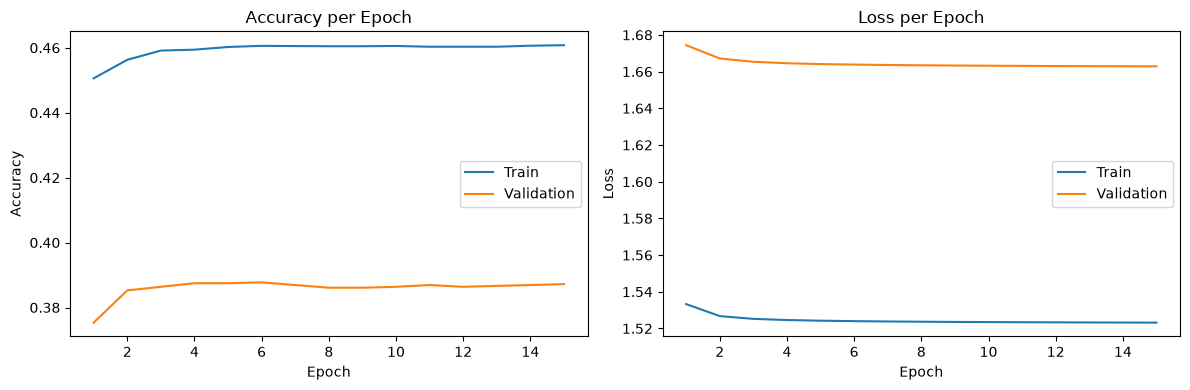

In [12]:
plot_training_curves(history)

## 12. Final Evaluation on the Test Set

The test set was never seen during training or validation. Evaluating on it gives an **unbiased estimate of real-world performance**.

`evaluate_model()` reports:
- **Accuracy** - percentage of tweets classified correctly overall
- **Per-class Precision, Recall, F1** - how well the model handles each individual emotion
- **Confusion Matrix** - which emotions are confused with each other

The confusion matrix is the most informative output: it reveals not just how often the model is wrong, but *what kind* of mistakes it makes (e.g., sadness predicted as worry).

In [13]:
model = combine_into_pipeline(vectorizer, classifier)
y_pred = evaluate_model(model, X_test, y_test)

Accuracy: 38.24%

Classification Report:
              precision    recall  f1-score   support

   happiness       0.41      0.34      0.37      1039
        hate       0.59      0.06      0.12       265
        love       0.54      0.33      0.41       760
     neutral       0.37      0.62      0.46      1724
      relief       0.75      0.01      0.02       305
     sadness       0.42      0.18      0.25      1032
    surprise       0.78      0.02      0.03       437
       worry       0.35      0.53      0.42      1690

    accuracy                           0.38      7252
   macro avg       0.52      0.26      0.26      7252
weighted avg       0.44      0.38      0.35      7252



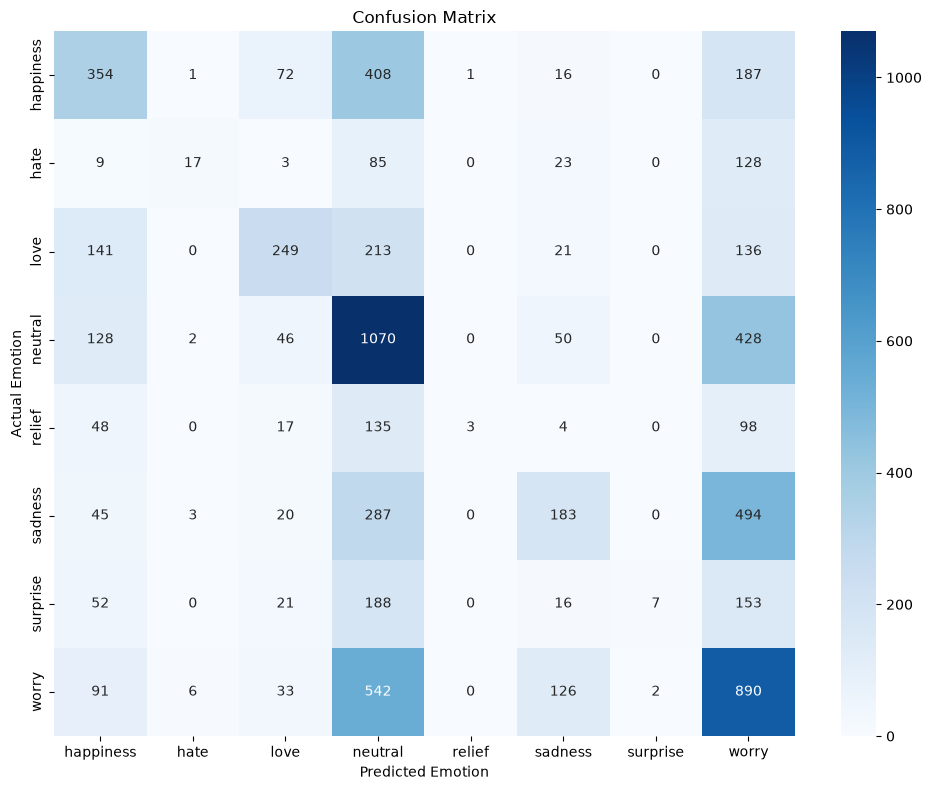

In [14]:
emotion_labels = sorted(df[config.LABEL_COLUMN].unique())
plot_confusion_matrix(y_test, y_pred, labels=emotion_labels)

## 13. Save the Trained Model

The trained pipeline (vectorizer + classifier together) is saved to `models/emotion_model.pkl` using `save_model()`. This allows the model to be loaded and used for prediction later without retraining from scratch.

In [15]:
save_model(model, path=config.MODEL_SAVE_PATH)

Model saved to: models/emotion_model.pkl


## 14. Try the Model on Your Own Sentences

Load the saved model and test it on custom input sentences. This is the final end-to-end check: raw text goes in, a predicted emotion comes out. It verifies the full pipeline works correctly from input to prediction.

In [16]:
my_sentences = [
    "I am so happy today, everything is going great!",
    "I can't believe this happened, I'm furious right now.",
    "I feel so alone and sad tonight.",
]

predictions = predict_emotion(model, my_sentences)

for sentence, emotion in zip(my_sentences, predictions):
    print(f"{emotion:12s} -> {sentence}")

happiness    -> I am so happy today, everything is going great!
worry        -> I can't believe this happened, I'm furious right now.
sadness      -> I feel so alone and sad tonight.


## 15. Conclusion & Key Findings

### Results Summary

| Metric | Value |
|--------|-------|
| Emotion classes | 8 |
| Training set size | ~27,800 tweets (70%) |
| Validation set size | ~3,970 tweets (10%) |
| Test set size | ~7,940 tweets (20%) |
| TF-IDF features | 5,000 (unigrams + bigrams) |
| Training epochs | 15 |

### Key Insights

1. **Data quality matters** - Removing 91 duplicate rows and 5 ambiguous or imbalanced emotion classes significantly improved the reliability of evaluation metrics.

2. **TF-IDF + SGD is a strong baseline** - A linear model with bag-of-words features achieves competitive accuracy on short social media text without requiring deep learning or large pretrained models.

3. **Class imbalance affects per-class F1** - Emotions with fewer training samples tend to have lower recall. Future work could apply class-weight adjustments or oversampling techniques.

4. **Modular design enables maintainability** - Each pipeline stage is an independent `src/` module. Swapping the classifier or feature extractor requires changing only one file.

### Possible Improvements

- Replace TF-IDF with sentence embeddings (e.g., `sentence-transformers`) for better semantic understanding
- Apply class-weight balancing to improve recall on minority emotions
- Use character n-grams to better handle slang and misspellings common in tweets
- Experiment with ensemble classifiers (Random Forest, SVM)